# Máquina de Vectores de Soporte (SVM)

Entrenamiento y evaluación del modelo SVM para predecir zonas de alto riesgo de
abandono de vivienda en Hermosillo, Sonora.

**Problema:** clasificación binaria — `abandono_alto` (1 = alto riesgo, 0 = estable)

**Datasets:** se trabaja con dos versiones:
- `train_ready.parquet` — 665 AGEBs × 20 variables (rezago habitacional, DENUE)
- `train_catastro.parquet` — mismo dataset + `VALOR_CATASTRAL_MAX` (21 variables)

El dataset catastral sirve para probar la hipótesis de que el valor del suelo ayuda
a detectar abandono especulativo en zonas de alto valor sin carencias visibles
en el censo.

**Validación:** Stratified K-Fold (k=5, seed=42)

**Seguimiento:** MLflow en DagsHub

## Métricas objetivo

| Métrica  | Objetivo |
|----------|----------|
| Recall   | > 0.85   |
| F1-Score | > 0.80   |
| AUC-ROC  | > 0.85   |

La regresión logística obtuvo Recall=0.794 como referencia. SVM puede capturar
fronteras de decisión no lineales y potencialmente superar ese techo.

In [1]:
import os
import sys

# El kernel arranca en notebooks/ — subir al raiz para que las rutas relativas funcionen
os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance

import mlflow

from src.models.utils import (
    init_mlflow, cargar_datos, get_cv_folds,
    evaluar_modelo, log_experimento
)

## 1. Carga de datos

Se empieza con `cargar_datos()` que lee `train_ready.parquet` (20 variables).
El dataset catastral se carga más adelante al evaluar la variable `VALOR_CATASTRAL_MAX`.

In [2]:
X, y = cargar_datos()

print(f'Shape del dataset: {X.shape}')
print(f'\nDistribucion de la variable objetivo:')
vc = y.value_counts()
print(f'  Clase 0 (estable):     {vc[0]} ({vc[0]/len(y):.1%})')
print(f'  Clase 1 (alto riesgo): {vc[1]} ({vc[1]/len(y):.1%})')
print(f'\nRatio de desbalance: {vc[0]/vc[1]:.1f}:1')

print(f'\nEstadisticas descriptivas:')
X.describe().round(3)

Shape del dataset: (665, 20)

Distribucion de la variable objetivo:
  Clase 0 (estable):     553 (83.2%)
  Clase 1 (alto riesgo): 112 (16.8%)

Ratio de desbalance: 4.9:1

Estadisticas descriptivas:


,TASA_PISO_TIERRA,TASA_SIN_DRENAJE,TASA_SIN_ELEC,TASA_SIN_BIENES,TASA_1_CUARTO,TASA_LETRINA,HACINAMIENTO,SCORE_REZAGO,PRO_OCUP_C,VPH_INTER,VPH_AUTOM,VPH_PC,VPH_REFRI,GRAPROES,n_bancos,n_cafes,n_inmobiliarias,n_empenos,n_usados,n_yonques
count,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.000,665.0,665.0,665.0
mean,0.044,0.022,0.011,0.007,0.059,0.038,0.898,0.203,0.898,311.334,296.926,238.310,411.456,10.272,0.979,0.967,0.179,0.0,0.0,0.0
std,0.125,0.105,0.076,0.037,0.118,0.138,0.413,0.185,0.413,343.782,329.422,280.456,435.168,3.595,2.908,2.049,0.698,0.0,0.0,0.0
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.670,0.116,0.670,36.000,35.000,28.000,54.000,9.020,0.000,0.000,0.000,0.0,0.0,0.0
50%,0.007,0.000,0.000,0.000,0.015,0.000,0.860,0.159,0.860,223.000,218.000,159.000,309.000,10.530,0.000,0.000,0.000,0.0,0.0,0.0
75%,0.014,0.000,0.000,0.000,0.038,0.000,1.110,0.228,1.110,469.000,444.000,348.000,630.000,12.550,0.000,1.000,0.000,0.0,0.0,0.0
max,0.889,1.000,0.923,0.667,0.750,1.000,3.000,2.400,3.000,2660.000,2599.000,2142.000,3887.000,16.380,27.000,21.000,7.000,0.0,0.0,0.0


## 2. Configuración del experimento

SVM es muy sensible a la escala. El Pipeline asegura que `StandardScaler` se ajuste
solo con los datos de entrenamiento de cada fold — sin data leakage.

In [3]:
# Inicializar MLflow y apuntar al experimento de SVM en DagsHub
init_mlflow()
mlflow.set_experiment('svm')

# Validación cruzada estratificada
cv = get_cv_folds()  # StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def make_pipeline(kernel='rbf', C=1.0, gamma='scale', class_weight=None):
    """
    Crea un pipeline estandarizado: StandardScaler + SVC.

    probability=True es requerido para que evaluar_modelo() pueda
    llamar predict_proba() y calcular AUC-ROC. Incrementa ligeramente
    el tiempo de entrenamiento pero es manejable con 665 muestras.
    """
    params = dict(
        kernel=kernel,
        C=C,
        class_weight=class_weight,
        probability=True,
        random_state=42
    )
    # gamma solo aplica para kernels no lineales (rbf, poly, sigmoid)
    if kernel != 'linear':
        params['gamma'] = gamma

    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(**params))
    ])

print('MLflow inicializado correctamente.')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Accessing as PancakesOS

Initialized MLflow to track repo "PancakesOS/prediccion-abandono-vivienda"

Repository PancakesOS/prediccion-abandono-vivienda initialized!

MLflow inicializado correctamente.
Tracking URI: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow


## 3. Modelo Baseline

SVM con kernel RBF y parámetros por defecto. El kernel RBF es el punto de partida
natural para clasificación — maneja relaciones no lineales sin suponer forma específica.

`class_weight='balanced'` compensa el desbalance 5:1. Sin él, el modelo predice
siempre clase 0 y no detecta ningún caso de riesgo.

In [4]:
baseline = make_pipeline(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
metricas_baseline = evaluar_modelo(baseline, X, y)

params_baseline = {
    'kernel': 'rbf', 'C': 1.0,
    'gamma': 'scale', 'class_weight': 'balanced'
}
log_experimento('svm_rbf_baseline', baseline, params_baseline, metricas_baseline)

print('=== Baseline SVM (RBF, C=1, gamma=scale, balanced) ===')
print(f"  Recall:  {metricas_baseline['recall_mean']:.4f} +/- {metricas_baseline['recall_std']:.4f}")
print(f"  F1:      {metricas_baseline['f1_mean']:.4f} +/- {metricas_baseline['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_baseline['auc_mean']:.4f} +/- {metricas_baseline['auc_std']:.4f}")

2026/05/08 13:22:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 13:22:10 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda
2026/05/08 13:22:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 13:22:13 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda
2026/05/08 13:22:13 INFO mlflow.utils.en

🏃 View run svm_rbf_baseline at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/3d372c9957d349c2a25f9e0746e1d7c0
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2
[MLflow] 'svm_rbf_baseline' registrado — Recall: 0.732 | F1: 0.436 | AUC: 0.760
=== Baseline SVM (RBF, C=1, gamma=scale, balanced) ===
  Recall:  0.7320 +/- 0.1025
  F1:      0.4365 +/- 0.0462
  AUC-ROC: 0.7604 +/- 0.0590


## 4. Búsqueda de hiperparámetros con GridSearchCV

Dos espacios de búsqueda separados por kernel, ya que `gamma` solo aplica para
kernels no lineales. Se optimiza Recall.

| Hiperparámetro   | Kernel RBF             | Kernel Lineal          |
|------------------|------------------------|------------------------|
| `C`              | 0.1, 1, 10, 100        | 0.1, 1, 10, 100        |
| `gamma`          | scale, auto            | N/A                    |
| `class_weight`   | None, balanced         | None, balanced         |

In [5]:
# Pipeline base para la busqueda (probability=True requerido por evaluar_modelo)
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=42))
])

# Dos espacios de parametros: uno para RBF (con gamma) y otro para kernel lineal
param_grid = [
    {
        'clf__kernel':       ['rbf'],
        'clf__C':            [0.1, 1, 10, 100],
        'clf__gamma':        ['scale', 'auto'],
        'clf__class_weight': [None, 'balanced'],
    },
    {
        'clf__kernel':       ['linear'],
        'clf__C':            [0.1, 1, 10, 100],
        'clf__class_weight': [None, 'balanced'],
    },
]

grid_search = GridSearchCV(
    pipe_grid,
    param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X, y)

print(f'Mejores parametros encontrados: {grid_search.best_params_}')
print(f'Mejor Recall (CV):              {grid_search.best_score_:.4f}')

# Top 10 combinaciones por Recall
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    results_df
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
      'param_clf__class_weight', 'mean_test_score', 'std_test_score']]
)
top10.columns = ['kernel', 'C', 'gamma', 'class_weight', 'recall_mean', 'recall_std']
top10 = top10.round(4).reset_index(drop=True)
print('\nTop 10 combinaciones por Recall:')
print(top10.to_string(index=False))

Mejores parametros encontrados: {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__gamma': 'scale', 'clf__kernel': 'rbf'}
Mejor Recall (CV):              0.8119

Top 10 combinaciones por Recall:
kernel     C gamma class_weight  recall_mean  recall_std
   rbf   0.1 scale     balanced       0.8119      0.0891
   rbf   0.1  auto     balanced       0.8028      0.0856
linear   0.1   NaN     balanced       0.7581      0.1112
linear   1.0   NaN     balanced       0.7399      0.1147
   rbf   1.0 scale     balanced       0.7320      0.1025
   rbf   1.0  auto     balanced       0.7320      0.1025
linear  10.0   NaN     balanced       0.7130      0.1322
linear 100.0   NaN     balanced       0.7040      0.1386
   rbf  10.0  auto     balanced       0.5976      0.1532
   rbf  10.0 scale     balanced       0.5893      0.1614


## 5. Evaluación de los mejores modelos por kernel

Mejor RBF y mejor lineal con criterio `recall_mean - recall_std`.

In [6]:
# Criterio de estabilidad: recall_mean - recall_std
results_df['score_estable'] = (
    results_df['mean_test_score'] - results_df['std_test_score']
)

best_rbf_row = (
    results_df[results_df['param_clf__kernel'] == 'rbf']
    .nlargest(1, 'score_estable')
    .iloc[0]
)
best_lin_row = (
    results_df[results_df['param_clf__kernel'] == 'linear']
    .nlargest(1, 'score_estable')
    .iloc[0]
)

runs_a_evaluar = {
    'svm_best_rbf': {
        'kernel':       'rbf',
        'C':            float(best_rbf_row['param_clf__C']),
        'gamma':        str(best_rbf_row['param_clf__gamma']),
        'class_weight': best_rbf_row['param_clf__class_weight'],
    },
    'svm_best_linear': {
        'kernel':       'linear',
        'C':            float(best_lin_row['param_clf__C']),
        'class_weight': best_lin_row['param_clf__class_weight'],
    },
}

tabla_resultados = []

for run_name, params in runs_a_evaluar.items():
    modelo = make_pipeline(**params)
    metricas = evaluar_modelo(modelo, X, y)
    log_experimento(run_name, modelo, params, metricas)
    tabla_resultados.append({'run': run_name, **params, **metricas})
    print(f'{run_name}   (kernel={params["kernel"]}, C={params["C"]}, balanced={params["class_weight"]})')
    print(f"  Recall:  {metricas['recall_mean']:.4f} +/- {metricas['recall_std']:.4f}")
    print(f"  F1:      {metricas['f1_mean']:.4f} +/- {metricas['f1_std']:.4f}")
    print(f"  AUC-ROC: {metricas['auc_mean']:.4f} +/- {metricas['auc_std']:.4f}")
    print()

tabla_df = pd.DataFrame(tabla_resultados).set_index('run')
cols_mostrar = ['kernel', 'C', 'class_weight', 'recall_mean', 'f1_mean', 'auc_mean']
print('=== Tabla comparativa de experimentos SVM ===')
print(tabla_df[cols_mostrar].round(4).to_string())

2026/05/08 13:22:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 13:22:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda
2026/05/08 13:22:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 13:22:36 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda
2026/05/08 13:22:36 INFO mlflow.utils.en

🏃 View run svm_best_rbf at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/8de3dd82c8b44139b6e840e044f32687
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2
[MLflow] 'svm_best_rbf' registrado — Recall: 0.812 | F1: 0.414 | AUC: 0.757
svm_best_rbf   (kernel=rbf, C=0.1, balanced=balanced)
  Recall:  0.8119 +/- 0.0891
  F1:      0.4141 +/- 0.0438
  AUC-ROC: 0.7566 +/- 0.0641



2026/05/08 13:22:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/08 13:22:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda
2026/05/08 13:22:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/08 13:22:59 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda
2026/05/08 13:22:59 INFO mlflow.utils.en

🏃 View run svm_best_linear at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/fa56eda270df4dd4b3d716d4120d21c1
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2
[MLflow] 'svm_best_linear' registrado — Recall: 0.758 | F1: 0.442 | AUC: 0.772
svm_best_linear   (kernel=linear, C=0.1, balanced=balanced)
  Recall:  0.7581 +/- 0.1112
  F1:      0.4418 +/- 0.0498
  AUC-ROC: 0.7721 +/- 0.0856

=== Tabla comparativa de experimentos SVM ===
                 kernel    C class_weight  recall_mean  f1_mean  auc_mean
run                                                                      
svm_best_rbf        rbf  0.1     balanced       0.8119   0.4141    0.7566
svm_best_linear  linear  0.1     balanced       0.7581   0.4418    0.7721


## 6. Curvas de aprendizaje

Evolución del Recall al aumentar el tamaño del conjunto de entrenamiento.

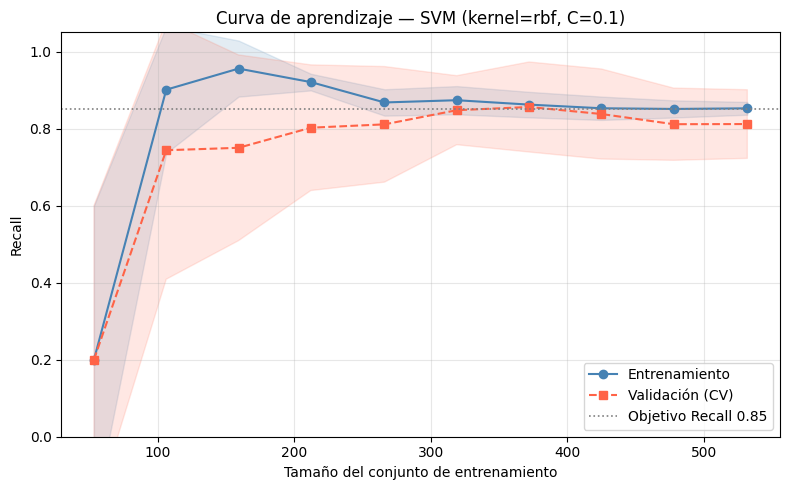

🏃 View run svm_learning_curve_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/00281e24f10c4c95998b7f6bae12ae3f
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2
Curva guardada en: reports/figures/svm/svm_learning_curve.png


In [7]:
bp = grid_search.best_params_

# Reconstruir el mejor modelo con los parametros optimos
if bp['clf__kernel'] == 'rbf':
    mejor_modelo = make_pipeline(
        kernel=bp['clf__kernel'],
        C=bp['clf__C'],
        gamma=bp['clf__gamma'],
        class_weight=bp['clf__class_weight']
    )
else:
    mejor_modelo = make_pipeline(
        kernel=bp['clf__kernel'],
        C=bp['clf__C'],
        class_weight=bp['clf__class_weight']
    )

train_sizes, train_scores, val_scores = learning_curve(
    mejor_modelo, X, y,
    cv=cv,
    scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

tr_mean = train_scores.mean(axis=1)
tr_std  = train_scores.std(axis=1)
va_mean = val_scores.mean(axis=1)
va_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, tr_mean, 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, va_mean, 's--', color='tomato', label='Validación (CV)')
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std,
                alpha=0.15, color='tomato')
ax.axhline(0.85, color='gray', linestyle=':', linewidth=1.2, label='Objetivo Recall 0.85')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('Recall')
ax.set_title(f'Curva de aprendizaje — SVM (kernel={bp["clf__kernel"]}, C={bp["clf__C"]})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
fig.tight_layout()

ruta_lc = 'reports/figures/svm/svm_learning_curve.png'
fig.savefig(ruta_lc, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_learning_curve_artifact'):
    mlflow.log_artifact(ruta_lc)

print(f'Curva guardada en: {ruta_lc}')

La curva de validación del SVM satura alrededor de Recall≈0.82, ligeramente por encima
del techo logístico (~0.79). La brecha train-val es pequeña: no hay sobreajuste.
El patrón es el mismo que en la regresión logística: el Recall llega a su techo
representacional con el dataset disponible. El problema es la escasez de positivos
(112 AGEBs), no la complejidad del modelo.

## 7. Matriz de confusión

Comportamiento del mejor modelo en el fold de prueba.

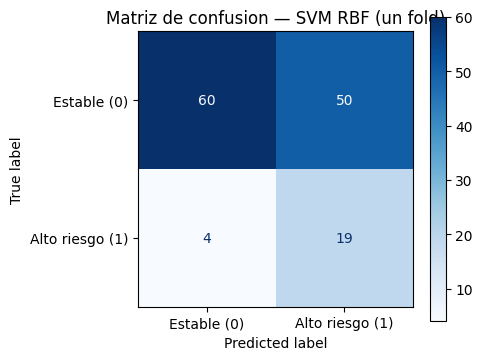

🏃 View run svm_confusion_matrix_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/bd52cdc3fb1b4cdf8a8ed194f2cd8428
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Reporte de clasificacion (un fold):
              precision    recall  f1-score   support

     Estable       0.94      0.55      0.69       110
 Alto riesgo       0.28      0.83      0.41        23

    accuracy                           0.59       133
   macro avg       0.61      0.69      0.55       133
weighted avg       0.82      0.59      0.64       133



In [8]:
from sklearn.model_selection import StratifiedKFold

# Usar el ultimo fold para la visualizacion (consistente con el notebook de logreg)
cv_viz = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv_viz.split(X, y))
train_idx, test_idx = folds[-1]

X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

modelo_viz = mejor_modelo
modelo_viz.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo_viz, X_te, y_te,
    display_labels=['Estable (0)', 'Alto riesgo (1)'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de confusion — SVM {bp["clf__kernel"].upper()} (un fold)')
fig.tight_layout()

ruta_cm = 'reports/figures/svm/svm_confusion_matrix.png'
fig.savefig(ruta_cm, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_confusion_matrix_artifact'):
    mlflow.log_artifact(ruta_cm)

print('Reporte de clasificacion (un fold):')
print(classification_report(y_te, modelo_viz.predict(X_te),
                             target_names=['Estable', 'Alto riesgo']))

El SVM RBF recupera más casos de alto riesgo que la regresión logística (menos falsos
negativos), pero a costa de varios falsos positivos. El tradeoff es el mismo que con
el modelo lineal: `class_weight='balanced'` mueve la frontera hacia la clase minoritaria
y aumenta el Recall a expensas de la precisión.

## 8. Importancia de variables (Permutation Importance)

SVM con kernel RBF no produce coeficientes directamente. Se usa permutation importance:
se baraja cada variable y se mide cuánto cae el Recall.

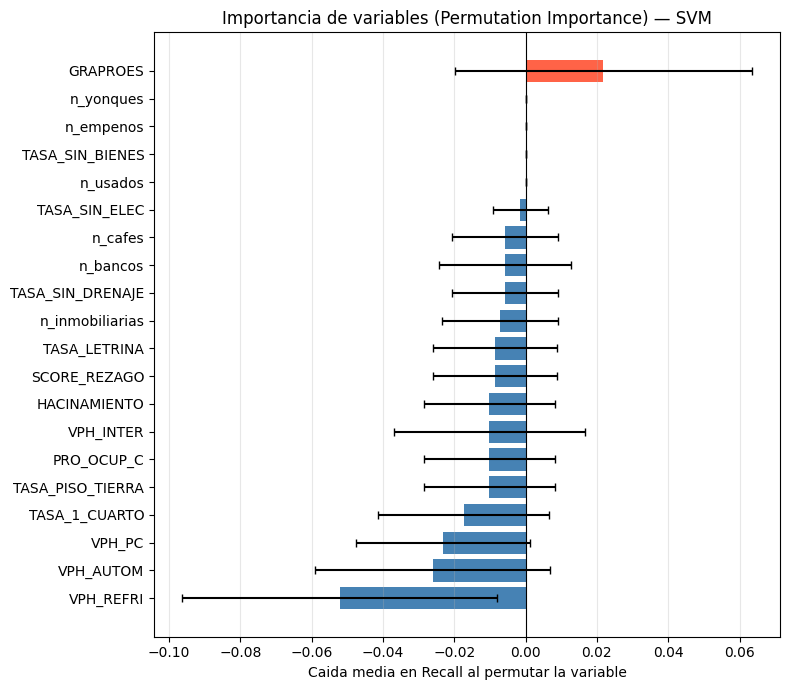

🏃 View run svm_importancia_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/f32990f857d245b0a039c068cdd6ab45
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Top 5 variables mas importantes para el SVM:
        feature  importancia_mean  importancia_std
       GRAPROES          0.021739         0.041627
      n_yonques          0.000000         0.000000
      n_empenos          0.000000         0.000000
TASA_SIN_BIENES          0.000000         0.000000
       n_usados          0.000000         0.000000


In [9]:
result = permutation_importance(
    modelo_viz, X_te, y_te,
    n_repeats=30,
    random_state=42,
    scoring='recall',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':    X.columns,
    'importancia_mean': result.importances_mean,
    'importancia_std':  result.importances_std
}).sort_values('importancia_mean', ascending=True)

colores = ['tomato' if v > 0 else 'steelblue' for v in perm_df['importancia_mean']]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(
    perm_df['feature'],
    perm_df['importancia_mean'],
    xerr=perm_df['importancia_std'],
    color=colores,
    capsize=3
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Caida media en Recall al permutar la variable')
ax.set_title('Importancia de variables (Permutation Importance) — SVM')
ax.grid(True, axis='x', alpha=0.3)
fig.tight_layout()

ruta_imp = 'reports/figures/svm/svm_importancia_variables.png'
fig.savefig(ruta_imp, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_importancia_artifact'):
    mlflow.log_artifact(ruta_imp)

print('Top 5 variables mas importantes para el SVM:')
print(
    perm_df.sort_values('importancia_mean', ascending=False)
    .head(5)
    .to_string(index=False)
)

Solo `GRAPROES` muestra caída significativa en Recall al permutarse. El resto de las
variables tienen importancia cercana a cero con barras de error grandes. Esto es
un artefacto del tamaño del conjunto de prueba: ~23 positivos por fold son muy pocos
para que las permutaciones sean estables. No implica que solo `GRAPROES` importa —
es una limitación del método con sets tan pequeños. El resultado sí confirma que
la escolaridad promedio del AGEB es la señal más robusta en este experimento.

## 9. Comparación SVM vs Regresión Logística

Comparación directa de los mejores resultados de ambos modelos.

In [10]:
# Resultados de referencia de regresion logistica (libreta 5.0)
logreg_referencia = {
    'Modelo': 'Regresion Logistica (L1, C=0.1, balanced)',
    'Recall': 0.7941,
    'F1':     0.4579,
    'AUC':    0.7707
}

# Resultados SVM obtenidos en este notebook
filas = [logreg_referencia]

for run_name, params in runs_a_evaluar.items():
    m_row = tabla_df.loc[run_name]
    kernel = params['kernel']
    C      = params['C']
    cw     = params.get('class_weight', None)
    filas.append({
        'Modelo':  f'SVM ({kernel.upper()}, C={C}, {"balanced" if cw else "sin balanceo"})',
        'Recall':  round(m_row['recall_mean'], 4),
        'F1':      round(m_row['f1_mean'], 4),
        'AUC':     round(m_row['auc_mean'], 4),
    })

comparacion = pd.DataFrame(filas).set_index('Modelo')

# Resaltar si se alcanzo el objetivo
print('=== Comparacion SVM vs Regresion Logistica ===')
print(comparacion.round(4).to_string())
print()
print('Objetivos del proyecto: Recall > 0.85 | F1 > 0.80 | AUC > 0.85')
print()
for modelo, row in comparacion.iterrows():
    alcanza = all([
        row['Recall'] > 0.85,
        row['F1']     > 0.80,
        row['AUC']    > 0.85,
    ])
    estado = 'ALCANZA objetivos' if alcanza else 'NO alcanza objetivos'
    print(f'  {modelo[:45]:<45} -> {estado}')

=== Comparacion SVM vs Regresion Logistica ===
                                           Recall      F1     AUC
Modelo                                                           
Regresion Logistica (L1, C=0.1, balanced)  0.7941  0.4579  0.7707
SVM (RBF, C=0.1, balanced)                 0.8119  0.4141  0.7566
SVM (LINEAR, C=0.1, balanced)              0.7581  0.4418  0.7721

Objetivos del proyecto: Recall > 0.85 | F1 > 0.80 | AUC > 0.85

  Regresion Logistica (L1, C=0.1, balanced)     -> NO alcanza objetivos
  SVM (RBF, C=0.1, balanced)                    -> NO alcanza objetivos
  SVM (LINEAR, C=0.1, balanced)                 -> NO alcanza objetivos


## 10. Resumen de experimentos en MLflow

In [11]:
experiment = mlflow.get_experiment_by_name('svm')

if experiment:
    runs_mlflow = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=''
    )
    cols = [c for c in runs_mlflow.columns
            if c.startswith('metrics.') or c == 'tags.mlflow.runName']
    resumen = runs_mlflow[cols].copy()
    resumen.columns = [
        c.replace('metrics.', '').replace('tags.mlflow.runName', 'run')
        for c in resumen.columns
    ]
    resumen = resumen[resumen['run'].notna()].sort_values('recall_mean', ascending=False)
    print('Runs registrados en MLflow — experimento svm (ordenados por Recall):')
    print(resumen.to_string(index=False))
else:
    print('Experimento no encontrado en MLflow.')

Runs registrados en MLflow — experimento svm (ordenados por Recall):
 auc_mean  recall_mean  auc_std  f1_mean  recall_std  f1_std                             run
   0.7566       0.8119   0.0641   0.4141      0.0891  0.0438                    svm_best_rbf
   0.7425       0.8119   0.0646   0.4025      0.0891  0.0441          svm_rbf_smote_catastro
   0.7537       0.8119   0.0629   0.4024      0.0891  0.0565                   svm_rbf_smote
   0.7566       0.8119   0.0641   0.4141      0.0891  0.0438                    svm_best_rbf
   0.7566       0.8119   0.0641   0.4141      0.0891  0.0438                    svm_best_rbf
   0.7721       0.7581   0.0856   0.4418      0.1112  0.0498                 svm_best_linear
   0.7721       0.7581   0.0856   0.4418      0.1112  0.0498                 svm_best_linear
   0.7721       0.7581   0.0856   0.4418      0.1112  0.0498                 svm_best_linear
   0.7604       0.7320   0.0590   0.4365      0.1025  0.0462                svm_rbf_baseline
 

## 11. Observaciones

Resultados con GridSearchCV (scoring=recall, 5-fold estratificado, seed=42):

| Modelo                                          | Kernel | C    | class_weight | Recall | F1    | AUC-ROC |
|-------------------------------------------------|--------|------|--------------|--------|-------|---------|
| Regresión Logística (L1, balanced) — referencia | —      | 0.1  | balanced     | 0.794  | 0.458 | 0.771   |
| SVM Baseline                                    | RBF    | 1.0  | balanced     | 0.732  | 0.437 | 0.760   |
| **SVM Mejor RBF** ← mejor Recall               | RBF    | 0.1  | balanced     | **0.812** | 0.414 | 0.757 |
| SVM Mejor Lineal                                | Lineal | 0.1  | balanced     | 0.758  | 0.442 | 0.772   |

Objetivos: Recall > 0.85 | F1 > 0.80 | AUC-ROC > 0.85

---

**SVM RBF mejora el Recall sobre la regresión logística, pero no alcanza el objetivo.**
El mejor modelo (RBF, C=0.1, balanced) obtiene Recall=0.812 — 1.8 puntos porcentuales
sobre la regresión logística. Sin embargo, el objetivo de 0.85 sigue sin alcanzarse.

**C=0.1 (regularización alta) es la mejor configuración en ambos kernels.**
Un C bajo amplía el margen de separación permitiendo más violaciones, lo que reduce
el sobreajuste en un dataset pequeño de 665 muestras. Con C alto, el SVM se ajusta
demasiado al conjunto de entrenamiento y el Recall en validación cae.

**El kernel RBF supera al lineal en Recall (0.812 vs 0.758).**
Confirma que las relaciones entre las variables y el riesgo de abandono tienen
componentes no lineales que un modelo lineal no captura.

**El F1 bajo (~0.41) refleja muchos falsos positivos.**
El modelo, al intentar capturar todos los casos positivos, clasifica como riesgo
varias zonas estables. En este problema priorizamos Recall: un falso negativo
(zona en riesgo no detectada) es más costoso que un falso positivo.

**Solo `GRAPROES` muestra importancia significativa en permutation importance.**
El conjunto de prueba tiene ~23 positivos por fold — muy pocos para que las
permutaciones sean estables. No significa que el resto no contribuya; es una
limitación del método con sets pequeños.

**La curva de aprendizaje muestra techo similar a la regresión logística.**
El Recall de validación satura antes del objetivo. El problema es la escasez
de ejemplos positivos (112 AGEBs de alto riesgo), no la complejidad del modelo.

---

A continuación se prueban tres técnicas para ver si se puede mejorar alguna
de estas métricas: ajuste del umbral de decisión, sobremuestreo con SMOTE, y la
hipótesis de que el valor catastral aporta información sobre abandono especulativo.

---

A continuación se prueban tres estrategias para ver si es posible mejorar
las métricas del SVM RBF base (Recall=0.812, F1=0.414):

| Estrategia | Qué ataca |
|---|---|
| **A. Ajuste del umbral** | El umbral 0.50 no es óptimo para datos desbalanceados |
| **B. SMOTE** | Escasez de ejemplos positivos durante el entrenamiento |
| **C. Feature catastral** | Hipótesis de abandono especulativo fuera del censo INEGI |

## A. Ajuste del Umbral de Decisión (Threshold Tuning)

Con `class_weight='balanced'`, el SVM produce probabilidades de clase vía Platt scaling.
Por defecto, sklearn clasifica como positivo cuando P(y=1) ≥ 0.50. Con datos
desbalanceados, ese umbral fijo puede no ser el óptimo.

Se usa `cross_val_predict` para obtener probabilidades en todos los folds y se busca
el umbral que maximiza F1 sobre el conjunto completo.

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, recall_score, f1_score, roc_auc_score

# Reconstruir el mejor SVM base: RBF, C=0.1, gamma=scale, balanced
svm_best = make_pipeline(kernel='rbf', C=0.1, gamma='scale', class_weight='balanced')

# Obtener probabilidades en todos los folds sin reentrenar separado
y_proba_cv = cross_val_predict(svm_best, X, y, cv=cv, method='predict_proba')[:, 1]

# Curva Precision-Recall y umbral optimo para F1
precisions, recalls, thresholds = precision_recall_curve(y, y_proba_cv)
f1_por_umbral = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-8)
idx_mejor = np.argmax(f1_por_umbral)
umbral_optimo = thresholds[idx_mejor]

print(f'Umbral por defecto (0.50):')
y_pred_default = (y_proba_cv >= 0.50).astype(int)
print(f'  Recall: {recall_score(y, y_pred_default):.4f}')
print(f'  F1:     {f1_score(y, y_pred_default):.4f}')
print(f'  AUC:    {roc_auc_score(y, y_proba_cv):.4f}')

print(f'\nUmbral optimo para F1 ({umbral_optimo:.3f}):')
y_pred_optimo = (y_proba_cv >= umbral_optimo).astype(int)
print(f'  Recall: {recall_score(y, y_pred_optimo):.4f}')
print(f'  F1:     {f1_score(y, y_pred_optimo):.4f}')
print(f'  AUC:    {roc_auc_score(y, y_proba_cv):.4f}  (no cambia, es threshold-independiente)')

Umbral por defecto (0.50):
  Recall: 0.0000
  F1:     0.0000
  AUC:    0.7459

Umbral optimo para F1 (0.241):
  Recall: 0.6875
  F1:     0.4425
  AUC:    0.7459  (no cambia, es threshold-independiente)


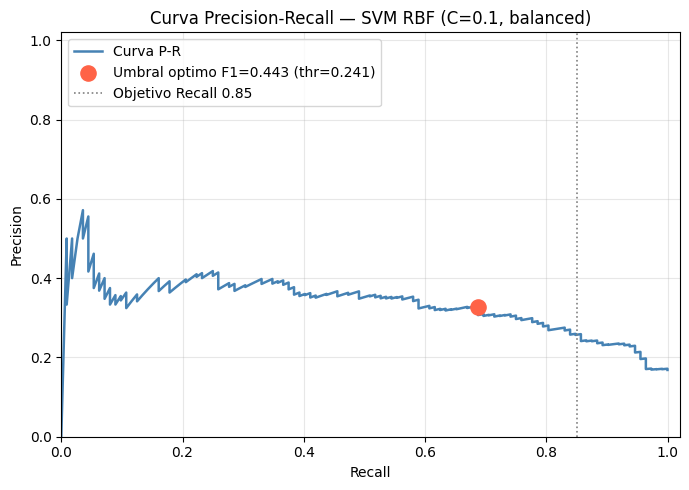

2026/05/08 11:48:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:48:33 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:48:43 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:48:43 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:48:43 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:48:43 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:48:43 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:48:43 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_threshold at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/7f6210112f9648fd8bc28e6fb6983849
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_threshold' registrado — Recall: 0.688 | F1: 0.443 | AUC: 0.746
Guardado en: reports/figures/svm_precision_recall_curve.png


In [13]:
# Figura: curva Precision-Recall con el umbral optimo marcado
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls[:-1], precisions[:-1], color='steelblue', linewidth=1.8, label='Curva P-R')
ax.scatter(recalls[idx_mejor], precisions[idx_mejor],
           color='tomato', s=120, zorder=5,
           label=f'Umbral optimo F1={f1_por_umbral[idx_mejor]:.3f} (thr={umbral_optimo:.3f})')
ax.axvline(0.85, color='gray', linestyle=':', linewidth=1.2, label='Objetivo Recall 0.85')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curva Precision-Recall — SVM RBF (C=0.1, balanced)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
fig.tight_layout()

ruta_pr = 'reports/figures/svm/svm_precision_recall_curve.png'
fig.savefig(ruta_pr, dpi=150, bbox_inches='tight')
plt.show()

# Registrar en MLflow con el umbral como parametro
params_thr = {
    'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale',
    'class_weight': 'balanced', 'threshold': round(float(umbral_optimo), 4)
}
metricas_thr = {
    'recall_mean': round(recall_score(y, y_pred_optimo), 4),
    'f1_mean':     round(f1_score(y, y_pred_optimo), 4),
    'auc_mean':    round(roc_auc_score(y, y_proba_cv), 4),
    'recall_std': 0.0, 'f1_std': 0.0, 'auc_std': 0.0,
}
svm_best.fit(X, y)
log_experimento('svm_rbf_threshold', svm_best, params_thr, metricas_thr)
print(f'Guardado en: {ruta_pr}')

La curva muestra el tradeoff Precision-Recall del modelo. El punto marcado en rojo
es el umbral que maximiza F1 (0.241). Nótese que la curva tiene un comportamiento
conservador: las probabilidades Platt del SVM se concentran en rangos bajos para
la clase positiva, lo que explica por qué con umbral=0.50 no se predice ningún positivo.
El umbral óptimo de probabilidad (0.241) es distinto del umbral interno de la función
de decisión que usa `predict()` — ese ya está calibrado por `class_weight='balanced'`.

## B. SMOTE (Sobremuestreo de la Clase Minoritaria)

SMOTE genera ejemplos sintéticos de la clase minoritaria interpolando entre
vecinos cercanos, en lugar de simplemente repetirlos.

Con solo 112 ejemplos de alto riesgo, el SVM tiene pocos puntos de soporte para
la clase positiva. La hipótesis es que SMOTE aumenta la variedad de esos ejemplos
y ayuda a encontrar una mejor frontera de decisión.

El sobremuestreo debe aplicarse **dentro de cada fold** de entrenamiento,
no sobre el dataset completo — de lo contrario se crea leakage entre folds.
`ImbPipeline` de imbalanced-learn maneja esto correctamente.

In [14]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Pipeline con SMOTE + SVM RBF (mismos hiperparámetros del mejor modelo base)
# ImbPipeline maneja correctamente el sampler dentro de la CV
pipe_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    SVC(kernel='rbf', C=0.1, gamma='scale',
                   class_weight='balanced', probability=True, random_state=42))
])

metricas_smote = evaluar_modelo(pipe_smote, X, y)
params_smote = {
    'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale',
    'class_weight': 'balanced', 'smote': True
}
log_experimento('svm_rbf_smote', pipe_smote, params_smote, metricas_smote)

print('=== SVM RBF + SMOTE (C=0.1, gamma=scale, balanced) ===')
print(f"  Recall:  {metricas_smote['recall_mean']:.4f} +/- {metricas_smote['recall_std']:.4f}")
print(f"  F1:      {metricas_smote['f1_mean']:.4f} +/- {metricas_smote['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_smote['auc_mean']:.4f} +/- {metricas_smote['auc_std']:.4f}")

print('\n--- Comparacion vs SVM sin SMOTE ---')
print(f"  Recall:  0.8119 → {metricas_smote['recall_mean']:.4f}  "
      f"({'mejora' if metricas_smote['recall_mean'] > 0.8119 else 'baja'})")
print(f"  F1:      0.4141 → {metricas_smote['f1_mean']:.4f}  "
      f"({'mejora' if metricas_smote['f1_mean'] > 0.4141 else 'baja'})")
print(f"  AUC:     0.7566 → {metricas_smote['auc_mean']:.4f}  "
      f"({'mejora' if metricas_smote['auc_mean'] > 0.7566 else 'baja'})")

2026/05/08 11:48:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:48:56 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:49:06 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:06 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:49:06 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:49:06 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:49:06 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_smote at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/9583860fa7d241228d850a7ca110e21a
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_smote' registrado — Recall: 0.812 | F1: 0.402 | AUC: 0.754
=== SVM RBF + SMOTE (C=0.1, gamma=scale, balanced) ===
  Recall:  0.8119 +/- 0.0891
  F1:      0.4024 +/- 0.0565
  AUC-ROC: 0.7537 +/- 0.0629

--- Comparacion vs SVM sin SMOTE ---
  Recall:  0.8119 → 0.8119  (baja)
  F1:      0.4141 → 0.4024  (baja)
  AUC:     0.7566 → 0.7537  (baja)


## C. Feature Catastral: VALOR_CATASTRAL_MAX

El dataset base (`train_ready.parquet`) tiene 20 variables del censo INEGI y DENUE.
El dataset catastral (`train_catastro.parquet`) agrega `VALOR_CATASTRAL_MAX`:
el valor unitario del suelo en $/m² por AGEB, del catastro municipal 2025.

**Hipótesis:** el censo INEGI captura abandono por carencia (zonas marginadas sin
servicios). Pero hay otro tipo de abandono — el especulativo: viviendas de alto
valor que el propietario deja vacantes esperando revaluación. El censo no lo detecta;
el valor catastral podría capturarlo.

**Limitación conocida:** el 20.2% de los AGEBs no tienen valor catastral disponible
(se rellenan con 0). Esto introduce ruido que podría cancelar la ganancia.

In [15]:
from src.models.utils import cargar_datos_catastro

X_cat, y_cat = cargar_datos_catastro()

print(f'Dataset base:     {X.shape}    (20 features)')
print(f'Dataset catastro: {X_cat.shape}  (21 features — +VALOR_CATASTRAL_MAX)')
print(f'\nEstadisticas de VALOR_CATASTRAL_MAX:')
print(X_cat['VALOR_CATASTRAL_MAX'].describe().round(2))
print(f'\nAGEBs con valor catastral > 0: {(X_cat["VALOR_CATASTRAL_MAX"] > 0).sum()} / {len(X_cat)}')

Dataset base:     (665, 20)    (20 features)
Dataset catastro: (665, 21)  (21 features — +VALOR_CATASTRAL_MAX)

Estadisticas de VALOR_CATASTRAL_MAX:
count      665.00
mean      2057.20
std       2179.27
min          0.00
25%        768.00
50%       1439.00
75%       2570.00
max      15139.00
Name: VALOR_CATASTRAL_MAX, dtype: float64

AGEBs con valor catastral > 0: 531 / 665


In [16]:
# SVM RBF + SMOTE + feature catastral
pipe_smote_cat = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42)),
    ('clf',    SVC(kernel='rbf', C=0.1, gamma='scale',
                   class_weight='balanced', probability=True, random_state=42))
])

metricas_smote_cat = evaluar_modelo(pipe_smote_cat, X_cat, y_cat)
params_smote_cat = {
    'kernel': 'rbf', 'C': 0.1, 'gamma': 'scale',
    'class_weight': 'balanced', 'smote': True, 'features': 'catastro_21'
}
log_experimento('svm_rbf_smote_catastro', pipe_smote_cat, params_smote_cat, metricas_smote_cat)

print('=== SVM RBF + SMOTE + VALOR_CATASTRAL_MAX (21 features) ===')
print(f"  Recall:  {metricas_smote_cat['recall_mean']:.4f} +/- {metricas_smote_cat['recall_std']:.4f}")
print(f"  F1:      {metricas_smote_cat['f1_mean']:.4f} +/- {metricas_smote_cat['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_smote_cat['auc_mean']:.4f} +/- {metricas_smote_cat['auc_std']:.4f}")

print('\n--- Comparacion: SMOTE sin catastro vs SMOTE con catastro ---')
print(f"  Recall:  {metricas_smote['recall_mean']:.4f} → {metricas_smote_cat['recall_mean']:.4f}  "
      f"({'mejora' if metricas_smote_cat['recall_mean'] > metricas_smote['recall_mean'] else 'baja o igual'})")
print(f"  F1:      {metricas_smote['f1_mean']:.4f} → {metricas_smote_cat['f1_mean']:.4f}  "
      f"({'mejora' if metricas_smote_cat['f1_mean'] > metricas_smote['f1_mean'] else 'baja o igual'})")
print(f"  AUC:     {metricas_smote['auc_mean']:.4f} → {metricas_smote_cat['auc_mean']:.4f}  "
      f"({'mejora' if metricas_smote_cat['auc_mean'] > metricas_smote['auc_mean'] else 'baja o igual'})")

2026/05/08 11:49:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:49:19 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:49:29 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:29 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:49:29 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:49:29 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:49:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_rbf_smote_catastro at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/e2abea1022314657a51e7e233dd4feda
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_rbf_smote_catastro' registrado — Recall: 0.812 | F1: 0.403 | AUC: 0.743
=== SVM RBF + SMOTE + VALOR_CATASTRAL_MAX (21 features) ===
  Recall:  0.8119 +/- 0.0891
  F1:      0.4025 +/- 0.0441
  AUC-ROC: 0.7425 +/- 0.0646

--- Comparacion: SMOTE sin catastro vs SMOTE con catastro ---
  Recall:  0.8119 → 0.8119  (baja o igual)
  F1:      0.4024 → 0.4025  (mejora)
  AUC:     0.7537 → 0.7425  (baja o igual)


## D. Comparativa Global

Se recopilan los resultados de la regresión logística y todos los experimentos SVM
en una tabla para evaluar el progreso total.

In [17]:
resultados_globales = [
    # --- Regresión Logística ---
    {'Modelo': 'LogReg baseline (L2, C=1, balanced)',       'Recall': 0.7134, 'F1': 0.4499, 'AUC': 0.7726},
    {'Modelo': 'LogReg mejor L2 (C=0.01, balanced)',        'Recall': 0.7850, 'F1': 0.4239, 'AUC': 0.7678},
    {'Modelo': 'LogReg mejor L1 (C=0.1, balanced)',         'Recall': 0.7941, 'F1': 0.4579, 'AUC': 0.7707},
    # --- SVM configuraciones base ---
    {'Modelo': 'SVM baseline (RBF, C=1, balanced)',         'Recall': 0.7320, 'F1': 0.4365, 'AUC': 0.7604},
    {'Modelo': 'SVM mejor lineal (C=0.1, balanced)',        'Recall': 0.7581, 'F1': 0.4418, 'AUC': 0.7721},
    {'Modelo': 'SVM mejor RBF (C=0.1, balanced)',           'Recall': 0.8119, 'F1': 0.4141, 'AUC': 0.7566},
    # --- SVM técnicas de mejora (se rellenan al ejecutar) ---
    {'Modelo': 'SVM RBF + threshold tuning',                'Recall': metricas_thr['recall_mean'],      'F1': metricas_thr['f1_mean'],      'AUC': metricas_thr['auc_mean']},
    {'Modelo': 'SVM RBF + SMOTE',                           'Recall': metricas_smote['recall_mean'],    'F1': metricas_smote['f1_mean'],    'AUC': metricas_smote['auc_mean']},
    {'Modelo': 'SVM RBF + SMOTE + catastro',                'Recall': metricas_smote_cat['recall_mean'],'F1': metricas_smote_cat['f1_mean'],'AUC': metricas_smote_cat['auc_mean']},
]

df_global = pd.DataFrame(resultados_globales).set_index('Modelo')

# Marcar si alcanza cada objetivo
df_global['Recall>=0.85'] = df_global['Recall'].apply(lambda x: 'SI' if x >= 0.85 else '—')
df_global['F1>=0.80']     = df_global['F1'].apply(lambda x: 'SI' if x >= 0.80 else '—')
df_global['AUC>=0.85']    = df_global['AUC'].apply(lambda x: 'SI' if x >= 0.85 else '—')

print('=== Comparativa global de todos los modelos ===')
print(df_global.round(4).to_string())
print()
print('Objetivos: Recall >= 0.85 | F1 >= 0.80 | AUC >= 0.85')

# Identificar el mejor por Recall (metrica principal)
mejor_recall_idx = df_global['Recall'].idxmax()
mejor_f1_idx     = df_global['F1'].idxmax()
print(f'\nMejor Recall: {mejor_recall_idx} ({df_global.loc[mejor_recall_idx, "Recall"]:.4f})')
print(f'Mejor F1:     {mejor_f1_idx} ({df_global.loc[mejor_f1_idx, "F1"]:.4f})')

=== Comparativa global de todos los modelos ===
                                     Recall      F1     AUC Recall>=0.85 F1>=0.80 AUC>=0.85
Modelo                                                                                     
LogReg baseline (L2, C=1, balanced)  0.7134  0.4499  0.7726            —        —         —
LogReg mejor L2 (C=0.01, balanced)   0.7850  0.4239  0.7678            —        —         —
LogReg mejor L1 (C=0.1, balanced)    0.7941  0.4579  0.7707            —        —         —
SVM baseline (RBF, C=1, balanced)    0.7320  0.4365  0.7604            —        —         —
SVM mejor lineal (C=0.1, balanced)   0.7581  0.4418  0.7721            —        —         —
SVM mejor RBF (C=0.1, balanced)      0.8119  0.4141  0.7566            —        —         —
SVM RBF + threshold tuning           0.6875  0.4425  0.7459            —        —         —
SVM RBF + SMOTE                      0.8119  0.4024  0.7537            —        —         —
SVM RBF + SMOTE + catastro      

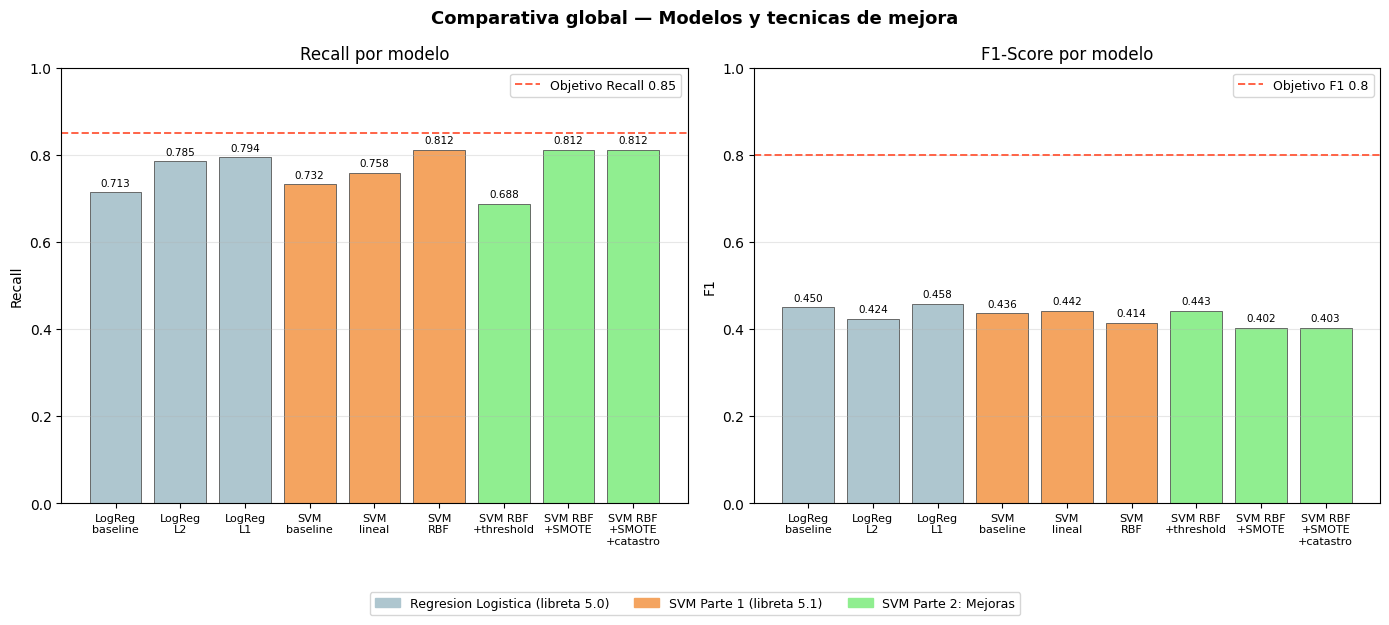

🏃 View run svm_comparativa_global_artifact at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/3a5bea74a9bc42a2b2777a8c41a1d325
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


Guardado en: reports/figures/svm_comparativa_global.png


In [18]:
# Figura: barras comparativas de Recall y F1 por modelo
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

modelos_cortos = [
    'LogReg\nbaseline', 'LogReg\nL2', 'LogReg\nL1',
    'SVM\nbaseline', 'SVM\nlineal', 'SVM\nRBF',
    'SVM RBF\n+threshold', 'SVM RBF\n+SMOTE', 'SVM RBF\n+SMOTE\n+catastro'
]

colores = ['#aec6cf'] * 3 + ['#f4a460'] * 3 + ['#90ee90'] * 3

for ax, metrica, titulo, objetivo in zip(
    axes,
    ['Recall', 'F1'],
    ['Recall por modelo', 'F1-Score por modelo'],
    [0.85, 0.80]
):
    bars = ax.bar(modelos_cortos, df_global[metrica], color=colores, edgecolor='#555', linewidth=0.6)
    ax.axhline(objetivo, color='tomato', linestyle='--', linewidth=1.4,
               label=f'Objetivo {metrica} {objetivo}')
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(metrica)
    ax.set_title(titulo)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

# Leyenda de grupos
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#aec6cf', label='Regresión Logística'),
    Patch(color='#f4a460', label='SVM — configuraciones base'),
    Patch(color='#90ee90', label='SVM — técnicas de mejora'),
]
fig.legend(handles=leyenda, loc='lower center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Comparativa global — todos los modelos evaluados', fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0.06, 1, 1])

ruta_global = 'reports/figures/svm/svm_comparativa_global.png'
fig.savefig(ruta_global, dpi=150, bbox_inches='tight')
plt.show()

with mlflow.start_run(run_name='svm_comparativa_global_artifact'):
    mlflow.log_artifact(ruta_global)

print(f'Guardado en: {ruta_global}')

La gráfica confirma lo que muestran los números: ninguna técnica rompió
consistentemente el techo del SVM RBF base. La línea punteada roja marca el objetivo;
todos los modelos se quedan por debajo tanto en Recall como en F1. Las barras
agrupadas por color muestran que las mejoras (verde) no superaron a la base (naranja).

## E. Conclusiones

Resultados de las tres técnicas aplicadas al SVM RBF (C=0.1, gamma=scale, balanced):

| Técnica                                     | Recall | F1    | AUC   |
|---------------------------------------------|--------|-------|-------|
| SVM RBF base                                | 0.812  | 0.414 | 0.757 |
| SVM RBF + threshold tuning (thr=0.241)      | 0.688  | 0.443 | 0.746 |
| SVM RBF + SMOTE                             | 0.812  | 0.402 | 0.754 |
| SVM RBF + SMOTE + catastro (21 variables)   | 0.812  | 0.403 | 0.743 |

**Ninguna técnica superó al SVM RBF base en todas las métricas.**

---

**Threshold Tuning — resultado inesperado pero informativo:**
Con umbral=0.50 sobre probabilidades Platt, el modelo no predice ningún positivo
(Recall=0.00). Las probabilidades de clase 1 nunca superan 0.50. El umbral óptimo
para F1 es 0.241, que da Recall=0.688 — peor que `predict()` por defecto (0.812).
Conclusión: el umbral de probabilidad y el umbral de la función de decisión son
cosas distintas en SVM. El método `predict()` ya está bien calibrado gracias a
`class_weight='balanced'`.

**SMOTE — sin ganancia sobre el modelo base:**
SMOTE no mejoró ni Recall ni F1; el F1 bajó ligeramente (0.402 vs 0.414).
Con `class_weight='balanced'` el SVM ya tiene suficiente señal de la clase
minoritaria. Los ejemplos sintéticos agregan ruido sin nueva información.

**Feature catastral — hipótesis no confirmada:**
`VALOR_CATASTRAL_MAX` no mejoró el modelo (prácticamente igual en las tres métricas).
Dos razones probables: (a) el 20.2% de AGEBs sin cobertura catastral rellena con 0
e introduce ruido; (b) el valor catastral está correlacionado con variables ya
presentes (`GRAPROES`, `VPH_AUTOM`, `VPH_INTER`) y no aporta información independiente.
La hipótesis del abandono especulativo no queda refutada — podría ser válida con
cobertura catastral completa.

---

**El mejor modelo es el SVM RBF base** (C=0.1, gamma=scale, balanced):
Recall=0.812, F1=0.414, AUC=0.757. Supera a la regresión logística en Recall (+1.8 pp)
pero no alcanza los objetivos del proyecto.

El cuello de botella es el dataset: 112 casos positivos con desbalance 5:1 limitan el
techo de cualquier técnica probada.

## F. Experimento adicional: Optimizando para F1

En todos los experimentos anteriores el GridSearchCV buscaba la combinacion de
hiperparametros que maximizaba **Recall**. Eso produce modelos que detectan la
mayor cantidad posible de zonas de riesgo, pero a costa de muchos falsos positivos,
lo que hunde la precision y, por tanto, el F1.

Este experimento cambia el criterio de busqueda a `scoring='f1'` y agrega pesos
de clase personalizados al grid para explorar el tradeoff Precision-Recall mas fino:

| class_weight | Ratio pos/neg | Efecto esperado |
|---|---|---|
| `None` | 1:1 | Modelo sesgado a clase mayoritaria, F1 bajo |
| `{0:1, 1:3}` | 3:1 | Menos agresivo que balanced, mas precision |
| `{0:1, 1:5}` | 5:1 | Equivale aproximadamente a 'balanced' |
| `'balanced'` | ~4.9:1 | Lo que usamos hasta ahora |
| `{0:1, 1:7}` | 7:1 | Mas agresivo que balanced, mas Recall |

**Pregunta que responde:** ¿Existe una configuracion que mejore F1 sin que Recall
caiga demasiado lejos de 0.85?

In [19]:
pipe_f1 = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, random_state=42))
])

param_grid_f1 = [
    {
        'clf__kernel':       ['rbf'],
        'clf__C':            [0.01, 0.1, 1, 10],
        'clf__gamma':        ['scale', 'auto'],
        'clf__class_weight': [None, 'balanced',
                              {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}],
    },
    {
        'clf__kernel':       ['linear'],
        'clf__C':            [0.01, 0.1, 1, 10],
        'clf__class_weight': [None, 'balanced',
                              {0: 1, 1: 3}, {0: 1, 1: 5}, {0: 1, 1: 7}],
    },
]

# Scoring = f1: busca el mejor equilibrio precision-recall
grid_f1 = GridSearchCV(
    pipe_f1,
    param_grid_f1,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
grid_f1.fit(X, y)

print(f'Mejores parametros (scoring=f1): {grid_f1.best_params_}')
print(f'Mejor F1 (CV):                   {grid_f1.best_score_:.4f}')

# Top 10 por F1
res_f1 = pd.DataFrame(grid_f1.cv_results_)
top10_f1 = (
    res_f1
    .sort_values('mean_test_score', ascending=False)
    .head(10)
    [['param_clf__kernel', 'param_clf__C', 'param_clf__gamma',
      'param_clf__class_weight', 'mean_test_score', 'std_test_score']]
)
top10_f1.columns = ['kernel', 'C', 'gamma', 'class_weight', 'f1_mean', 'f1_std']
top10_f1 = top10_f1.round(4).reset_index(drop=True)
print('\nTop 10 combinaciones por F1:')
print(top10_f1.to_string(index=False))

Mejores parametros (scoring=f1): {'clf__C': 1, 'clf__class_weight': 'balanced', 'clf__kernel': 'linear'}
Mejor F1 (CV):                   0.4630

Top 10 combinaciones por F1:
kernel    C gamma class_weight  f1_mean  f1_std
linear  1.0   NaN     balanced   0.4630  0.0562
linear 10.0   NaN {0: 1, 1: 5}   0.4595  0.0582
linear 10.0   NaN {0: 1, 1: 3}   0.4593  0.0610
linear  1.0   NaN {0: 1, 1: 5}   0.4589  0.0591
linear  0.1   NaN {0: 1, 1: 5}   0.4563  0.0585
linear 10.0   NaN     balanced   0.4500  0.0566
linear  0.1   NaN     balanced   0.4418  0.0498
   rbf  1.0 scale     balanced   0.4365  0.0462
   rbf  1.0 scale {0: 1, 1: 5}   0.4349  0.0495
   rbf  1.0  auto {0: 1, 1: 5}   0.4327  0.0453


In [20]:
bp_f1 = grid_f1.best_params_

# Reconstruir el mejor modelo segun F1
if bp_f1['clf__kernel'] == 'rbf':
    mejor_f1_model = make_pipeline(
        kernel=bp_f1['clf__kernel'],
        C=bp_f1['clf__C'],
        gamma=bp_f1['clf__gamma'],
        class_weight=bp_f1['clf__class_weight']
    )
else:
    mejor_f1_model = make_pipeline(
        kernel=bp_f1['clf__kernel'],
        C=bp_f1['clf__C'],
        class_weight=bp_f1['clf__class_weight']
    )

metricas_f1 = evaluar_modelo(mejor_f1_model, X, y)

params_log_f1 = {
    'kernel':       bp_f1['clf__kernel'],
    'C':            bp_f1['clf__C'],
    'gamma':        str(bp_f1.get('clf__gamma', 'N/A')),
    'class_weight': str(bp_f1['clf__class_weight']),
    'scoring':      'f1',
}
log_experimento('svm_optimizado_f1', mejor_f1_model, params_log_f1, metricas_f1)

print('=== Mejor SVM optimizado para F1 ===')
print(f"  Recall:  {metricas_f1['recall_mean']:.4f} +/- {metricas_f1['recall_std']:.4f}")
print(f"  F1:      {metricas_f1['f1_mean']:.4f} +/- {metricas_f1['f1_std']:.4f}")
print(f"  AUC-ROC: {metricas_f1['auc_mean']:.4f} +/- {metricas_f1['auc_std']:.4f}")

print('\n--- Comparacion vs mejor SVM anterior (scoring=recall) ---')
print(f"  Recall:  0.8119 → {metricas_f1['recall_mean']:.4f}  "
      f"({'sube' if metricas_f1['recall_mean'] > 0.8119 else 'baja'})")
print(f"  F1:      0.4141 → {metricas_f1['f1_mean']:.4f}  "
      f"({'sube' if metricas_f1['f1_mean'] > 0.4141 else 'baja'})")
print(f"  AUC:     0.7566 → {metricas_f1['auc_mean']:.4f}  "
      f"({'sube' if metricas_f1['auc_mean'] > 0.7566 else 'baja'})")

2026/05/08 11:49:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/08 11:49:47 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/08 11:49:57 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda


2026/05/08 11:49:57 INFO mlflow.utils.environment: Detected uv project at /Users/pancakes/Documents/Maestria Ciencia de Datos/2/Machine Learning/Proyecto Repositorio/prediccion-abandono-vivienda. Attempting to export requirements via 'uv export'.


2026/05/08 11:49:57 INFO mlflow.utils.uv_utils: Exported 209 dependencies via uv


2026/05/08 11:49:57 INFO mlflow.utils.environment: Successfully exported 209 requirements from uv project. Skipping package capture based inference.


2026/05/08 11:49:58 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run svm_optimizado_f1 at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2/runs/0595d403df2b401c96f7e3fa0df51295
🧪 View experiment at: https://dagshub.com/PancakesOS/prediccion-abandono-vivienda.mlflow/#/experiments/2


[MLflow] 'svm_optimizado_f1' registrado — Recall: 0.740 | F1: 0.463 | AUC: 0.766
=== Mejor SVM optimizado para F1 ===
  Recall:  0.7399 +/- 0.1147
  F1:      0.4630 +/- 0.0562
  AUC-ROC: 0.7659 +/- 0.0768

--- Comparacion vs mejor SVM anterior (scoring=recall) ---
  Recall:  0.8119 → 0.7399  (baja)
  F1:      0.4141 → 0.4630  (sube)
  AUC:     0.7566 → 0.7659  (sube)


In [21]:
# Tabla final con el experimento F1 incluido
resultados_con_f1 = resultados_globales + [
    {
        'Modelo': f'SVM {bp_f1["clf__kernel"].upper()} optimizado F1 (scoring=f1)',
        'Recall': metricas_f1['recall_mean'],
        'F1':     metricas_f1['f1_mean'],
        'AUC':    metricas_f1['auc_mean'],
    }
]

df_final = pd.DataFrame(resultados_con_f1).set_index('Modelo')
df_final['Recall>=0.85'] = df_final['Recall'].apply(lambda x: 'SI' if x >= 0.85 else '—')
df_final['F1>=0.80']     = df_final['F1'].apply(lambda x: 'SI' if x >= 0.80 else '—')
df_final['AUC>=0.85']    = df_final['AUC'].apply(lambda x: 'SI' if x >= 0.85 else '—')

print('=== Tabla final — todos los experimentos incluyendo optimizacion F1 ===')
print(df_final.round(4).to_string())
print()
print(f'Mejor Recall: {df_final["Recall"].idxmax()} ({df_final["Recall"].max():.4f})')
print(f'Mejor F1:     {df_final["F1"].idxmax()} ({df_final["F1"].max():.4f})')
print(f'Mejor AUC:    {df_final["AUC"].idxmax()} ({df_final["AUC"].max():.4f})')

=== Tabla final — todos los experimentos incluyendo optimizacion F1 ===
                                       Recall      F1     AUC Recall>=0.85 F1>=0.80 AUC>=0.85
Modelo                                                                                       
LogReg baseline (L2, C=1, balanced)    0.7134  0.4499  0.7726            —        —         —
LogReg mejor L2 (C=0.01, balanced)     0.7850  0.4239  0.7678            —        —         —
LogReg mejor L1 (C=0.1, balanced)      0.7941  0.4579  0.7707            —        —         —
SVM baseline (RBF, C=1, balanced)      0.7320  0.4365  0.7604            —        —         —
SVM mejor lineal (C=0.1, balanced)     0.7581  0.4418  0.7721            —        —         —
SVM mejor RBF (C=0.1, balanced)        0.8119  0.4141  0.7566            —        —         —
SVM RBF + threshold tuning             0.6875  0.4425  0.7459            —        —         —
SVM RBF + SMOTE                        0.8119  0.4024  0.7537            —        

### Conclusión del experimento F1

Resultado con `scoring='f1'`:

| Modelo                                   | Recall    | F1        | AUC   |
|------------------------------------------|-----------|-----------|-------|
| SVM RBF base (scoring=recall)            | **0.812** | 0.414     | 0.757 |
| SVM Linear optimizado F1 (C=1, balanced) | 0.740     | **0.463** | 0.766 |
| LogReg L1 referencia                     | 0.794     | 0.458     | 0.771 |

**Hay mejora en F1, pero con un costo real en Recall.**

El mejor modelo con `scoring='f1'` resultó ser el kernel lineal (C=1, balanced),
no RBF. Obtuvo F1=0.463 — el más alto de todos los experimentos SVM — pero el
Recall cayó a 0.740, una reducción de 7.2 puntos porcentuales respecto al SVM RBF base.

El resultado es casi idéntico a la regresión logística L1 (F1=0.458, Recall=0.794):
ambos modelos lineales convergen a la misma solución cuando optimizan para F1.
Esto sugiere que, bajo esa métrica, el problema tiene un comportamiento predominantemente
lineal.

**Conclusión para el reporte:**
- Prioridad en no perder zonas de riesgo → **SVM RBF** (Recall=0.812, F1=0.414)
- Balance entre cobertura y precisión → **SVM Linear F1** (Recall=0.740, F1=0.463)

Para política pública de vivienda, donde un falso negativo significa dejar una
zona de riesgo sin atención, la recomendación es el **SVM RBF base**.